In [39]:
from pathlib import Path
import importlib.util
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplconfig_portfolio_robustness')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
from tqdm.auto import tqdm

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


In [40]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'experiments' else Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError(f'Project root not found from cwd={Path.cwd()}')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load import load_returns_csv
from src.clustering.representations import raw_return_representation
from src.clustering.selection import DEFAULT_K_CANDIDATES, select_non_overlapping_windows
from src.clustering.evaluation import evaluate_clustering_config, recommend_global_k

CLUSTER_DIR = PROJECT_ROOT / 'data' / 'processed' / 'clustering'
PLOTS_DIR = CLUSTER_DIR / 'plots'
CLUSTER_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RETURNS_PATH = PROJECT_ROOT / 'data' / 'processed' / 'returns_final.csv'
RESULTS_PATH = CLUSTER_DIR / 'k_selection_results.csv'
RECOMMENDED_PATH = CLUSTER_DIR / 'recommended_k.csv'
WINDOWS_PATH = CLUSTER_DIR / 'selected_windows.csv'

PROJECT_ROOT, CLUSTER_DIR


(PosixPath('/Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness'),
 PosixPath('/Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering'))

## 1) Configuration

In [41]:
WINDOW_LENGTH = 756
N_WINDOWS = 5
K_CANDIDATES = DEFAULT_K_CANDIDATES

CONFIGS = [
    {'method': 'kmeans', 'distance': 'euclidean'},
    {'method': 'kmedoids', 'distance': 'dtw'},
]

RANDOM_STATE = 42
DTW_N_JOBS = -1
DTW_USE_GPU = False  

print('K candidates:', K_CANDIDATES)
print('Configs:', CONFIGS)


K candidates: [2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
Configs: [{'method': 'kmeans', 'distance': 'euclidean'}, {'method': 'kmedoids', 'distance': 'dtw'}]


## 2) Load Data

In [42]:
returns = load_returns_csv(RETURNS_PATH)
print('returns shape:', returns.shape)
print('start/end:', returns.index.min().date(), returns.index.max().date())
returns.head()


returns shape: (5256, 389)
start/end: 2005-01-04 2025-11-21


,A,MOH,NDAQ,MU,MTD,MTCH,MTB,MSI,MSFT,MS,MRK,MPWR,MOS,MO,MCHP,MNST,MMM,MMC,MLM,MKC,MHK,MGM,MET,MDT,MDLZ,MCO,NDSN,NEE,NEM,NFLX,PEP,PEG,PCG,PCAR,PAYX,OXY,ORLY,ORCL,ON,OMC,OKE,ODFL,O,NVR,NVDA,NUE,NTRS,NTAP,NSC,NRG,NOC,NKE,NI,MCK,MCD,PFG,INTC,JBL,JBHT,J,IVZ,ITW,IT,AAPL,IRM,IPG,IP,INTU,INCY,MAS,IFF,IEX,IDXX,IBM,HUM,HUBB,HSY,HST,HSIC,HRL,HPQ,JCI,JKHY,JNJ,JPM,MAR,MAA,LVS,LUV,LRCX,LOW,LNT,LMT,LLY,LKQ,LIN,LII,LHX,LH,LEN,...,APA,AOS,AON,BG,BIIB,AME,CAH,CHRW,CHD,AMD,CDNS,CCL,CCI,CBRE,CB,CAT,CAG,BK,C,BXP,BSX,BRO,BRK-B,BMY,BLK,BKR,BKNG,DTE,AMT,GOOG,EXR,FRT,ADI,EXPD,GD,AEP,EXC,EW,EVRG,GS,ADBE,ETR,ETN,AES,GE,GWW,ADM,F,FICO,ADP,GPN,AEE,FI,DVA,FFIV,GRMN,FE,FDX,FDS,ADSK,FCX,FIS,GOOGL,FITB,FAST,GEN,GPC,ESS,ED,EL,EIX,ABT,GLW,EG,EFX,ECL,ES,EBAY,EA,ACGL,HIG,DVN,AFL,ELV,EME,GL,EOG,HAL,ERIE,EQT,EQR,EQIX,EMN,HAS,EMR,GILD,HBAN,GIS,HD,ACN
2005-01-04,-0.026382,0.030193,-0.029557,-0.028333,-0.013902,-0.019510,-0.004344,-0.019930,0.003740,-0.010734,-0.004158,-0.024803,-0.054939,0.006927,-0.017307,-0.041643,-0.008132,0.003039,-0.023282,0.000527,-0.011693,-0.007674,-0.006225,-0.004653,-0.004013,-0.015078,-0.020686,-0.012179,-0.018650,-0.021816,-0.007123,-0.008440,-0.007571,-0.032982,-0.020060,-0.011141,-0.003327,-0.026100,-0.069820,-0.000591,-0.016864,-0.007094,-0.009192,-0.028941,-0.047074,-0.006541,-0.008644,-0.039756,-0.008162,-0.019769,-0.021435,-0.014224,-0.015646,-0.012874,0.008171,-0.000986,-0.019939,-0.024321,-0.023361,0.000216,-0.024096,-0.006294,-0.016194,0.010270,-0.028514,-0.017844,-0.024041,-0.032867,-0.038382,-0.021329,-0.028504,-0.019046,-0.000913,-0.010741,-0.002058,-0.017119,0.010670,-0.008824,0.003526,-0.001634,-0.006651,0.005926,-0.033525,-0.003180,-0.010307,-0.015350,-0.003671,0.019584,-0.028624,-0.035984,-0.020876,-0.004271,-0.016971,-0.013333,-0.040404,-0.014325,-0.008040,-0.044237,-0.004312,-0.045893,...,-0.008078,-0.022510,-0.009330,-0.028957,-0.023080,-0.025807,-0.028332,-0.004370,-0.012681,-0.056049,-0.032727,-0.004536,-0.015844,-0.005766,-0.002599,-0.011045,-0.003421,-0.015403,-0.008494,-0.017125,-0.003500,0.001363,-0.015178,-0.011010,-0.003035,0.002661,0.006321,-0.000233,-0.013216,-0.040501,0.009782,-0.013886,-0.027205,-0.016594,-0.025975,-0.003821,-0.006708,-0.021350,-0.007979,-0.006479,-0.026422,-0.007674,-0.026993,-0.036900,-0.012025,-0.016897,-0.010929,-0.003399,-0.041277,-0.015964,-0.017845,-0.007925,-0.012744,0.003811,-0.049522,-0.038866,-0.003303,-0.017864,-0.020344,-0.064921,-0.039505,-0.008229,-0.040501,-0.007150,-0.027960,-0.030153,-0.009170,-0.021144,-0.003002,-0.020179,-0.002519,-0.010071,-0.015372,-0.009376,-0.034892,-0.012716,-0.009730,-0.024537,-0.028581,-0.013123,-0.011047,-0.002419,-0.001007,-0.013333,-0.019586,-0.010039,-0.015778,0.001052,0.005500,-0.007944,-0.006206,-0.019204,-0.089179,-0.002618,-0.011645,-0.024475,-0.006085,-0.003067,-0.012761,-0.023512
2005-01-05,-0.000430,-0.006444,-0.010151,-0.011149,0.000199,-0.007803,-0.001518,-0.011962,-0.002236,-0.005786,0.006746,-0.040463,-0.023514,-0.001801,-0.030528,-0.048281,-0.012236,-0.009091,-0.000391,-0.012635,-0.010704,0.017998,-0.006515,-0.007431,-0.008060,-0.004306,-0.010046,-0.012876,0.002405,-0.039449,0.001163,-0.013262,-0.012206,-0.032271,-0.007027,-0.005543,-0.001113,0.003063,-0.031477,-0.004731,-0.006934,-0.057731,-0.050827,-0.010499,0.009346,-0.008779,-0.003828,0.001593,0.018444,-0.012389,0.015238,-0.011969,-0.005904,-0.000326,-0.007793,-0.011352,-0.009730,-0.020773,-0.022759,-0.017461,0.008231,0.005897,-0.012346,0.008758,0.012431,-0.001514,0.014390,-0.011328,-0.002158,-0.014322,-0.001222,-0.021486,0.004205,-0.002068,0.020618,-0.001844,-0.024209,-0.034421,-0.001025,-0.009493,0.004305,-0.004489,0.005451,-0.000637,0.002083,0.000649,-0.037091,-0.012334,0.000000,-0.033968,-0.008458,-0.006076,0.025146,0.010450,-0.044737,-0.020299,-0.002026,-0.010789,-0.012580,-0.009358,...,-0.003342,-0.032799,-0.026969,-0.025122,0.001235,-0.018716,-0.002340,0.008963,0.003364,-0.022761,0.000752,-0.001753,0.024768,-0.028694,-0.000710,-0.019145,-0.009955,0.001533,0.012536,-0.0393

## 3) Non-overlapping window selection

In [43]:
windows_df = select_non_overlapping_windows(
    returns_index=returns.index,
    window_length=WINDOW_LENGTH,
    n_windows=N_WINDOWS,
)
windows_df.to_csv(WINDOWS_PATH, index=False)
print('Saved:', WINDOWS_PATH)
display(windows_df)


Saved: /Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering/selected_windows.csv


,window_id,start_iloc,end_iloc,start_date,end_date,n_obs
0,W1,0,755,2005-01-04,2008-01-04,756
1,W2,1125,1880,2009-06-24,2012-06-21,756
2,W3,2250,3005,2013-12-11,2016-12-09,756
3,W4,3375,4130,2018-06-01,2021-06-02,756
4,W5,4500,5255,2022-11-17,2025-11-21,756


In [44]:
# overlap sanity check
has_overlap = False
for i in range(len(windows_df) - 1):
    if windows_df.loc[i + 1, 'start_iloc'] <= windows_df.loc[i, 'end_iloc']:
        has_overlap = True
        break
print('Any overlap:', has_overlap)


Any overlap: False


## 4) Create Task list

In [45]:
tasks = []
for _, w in windows_df.iterrows():
    start_iloc = int(w['start_iloc'])
    end_iloc = int(w['end_iloc'])
    window_returns = returns.iloc[start_iloc:end_iloc + 1]
    asset_matrix = raw_return_representation(window_returns)

    for cfg in CONFIGS:
        for k in K_CANDIDATES:
            tasks.append((w, cfg, int(k), asset_matrix))

print('Total tasks:', len(tasks))


Total tasks: 100


## 5) Clustering Config Evaluation

In [46]:
rows = []
for w, cfg, k, asset_matrix in tqdm(tasks, desc='Evaluating configs', unit='cfg'):
    if cfg['method'] == 'kmedoids' and cfg['distance'] == 'dtw':
        rows.append({
            'window_id': w['window_id'],
            'window_start': pd.Timestamp(w['start_date']).date().isoformat(),
            'window_end': pd.Timestamp(w['end_date']).date().isoformat(),
            'method': cfg['method'],
            'distance': cfg['distance'],
            'k': k,
            'silhouette_score': np.nan,
            'davies_bouldin': np.nan,
            'cluster_balance': np.nan,
            'n_clusters_found': np.nan,
            'status': 'skip',
            'notes': 'tslearn is not installed; skipping DTW-based evaluation',
        })
        continue

    out = evaluate_clustering_config(
        asset_return_matrix=asset_matrix,
        method=cfg['method'],
        distance=cfg['distance'],
        k=k,
        random_state=RANDOM_STATE,
        dtw_n_jobs=DTW_N_JOBS,
        dtw_use_gpu=DTW_USE_GPU,
    )

    rows.append({
        'window_id': w['window_id'],
        'window_start': pd.Timestamp(w['start_date']).date().isoformat(),
        'window_end': pd.Timestamp(w['end_date']).date().isoformat(),
        'method': cfg['method'],
        'distance': cfg['distance'],
        'k': k,
        'silhouette_score': out.get('silhouette_score'),
        'davies_bouldin': out.get('davies_bouldin'),
        'cluster_balance': out.get('cluster_balance'),
        'n_clusters_found': out.get('n_clusters_found'),
        'status': out.get('status', 'error'),
        'notes': out.get('notes', ''),
    })

results_df = pd.DataFrame(rows).sort_values(['method', 'distance', 'window_id', 'k']).reset_index(drop=True)
results_df.to_csv(RESULTS_PATH, index=False)

print('Saved:', RESULTS_PATH)
print('shape:', results_df.shape)
display(results_df.head(20))


tslearn installed: True


Evaluating configs:   0%|          | 0/100 [00:00<?, ?cfg/s]

Saved: /Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering/k_selection_results.csv
shape: (100, 12)


,window_id,window_start,window_end,method,distance,k,silhouette_score,davies_bouldin,cluster_balance,n_clusters_found,status,notes
0,W1,2005-01-04,2008-01-04,kmeans,euclidean,2,0.148775,4.986892,0.388175,2,ok,
1,W1,2005-01-04,2008-01-04,kmeans,euclidean,3,0.123433,4.068359,0.831603,3,ok,
2,W1,2005-01-04,2008-01-04,kmeans,euclidean,4,0.117908,3.459662,1.213332,4,ok,
3,W1,2005-01-04,2008-01-04,kmeans,euclidean,5,0.074492,3.270323,1.176760,5,ok,
4,W1,2005-01-04,2008-01-04,kmeans,euclidean,6,0.063186,2.811413,1.385184,6,ok,
5,W1,2005-01-04,2008-01-04,kmeans,euclidean,8,0.034155,3.085561,1.470183,8,ok,
6,W1,2005-01-04,2008-01-04,kmeans,euclidean,10,0.011259,3.543585,1.215667,10,ok,
7,W1,2005-01-04,2008-01-04,kmeans,euclidean,12,0.006680,2.331755,1.704095,12,ok,
8,W1,2005-01-04,2008-01-04,kmeans,euclidean,15,-0.057314,2.328971,1.688427,15,ok,
9,W1,2005-01-04,2008-01-04,kmeans,euclidean,20,0.007717,1.903466,1.993008,20,ok,


## 6) Status / Coverage

In [47]:
status_counts = (
    results_df
    .groupby(['method', 'distance', 'status'])
    .size()
    .reset_index(name='n')
    .sort_values(['method', 'distance', 'status'])
)
display(status_counts)


,method,distance,status,n
0,kmeans,euclidean,ok,50
1,kmedoids,dtw,ok,50


In [48]:
ok_df = results_df[results_df['status'] == 'ok'].copy()
print('ok rows:', len(ok_df))
if not ok_df.empty:
    display(ok_df.describe(include='all'))


ok rows: 100


,window_id,window_start,window_end,method,distance,k,silhouette_score,davies_bouldin,cluster_balance,n_clusters_found,status,notes
count,100,100,100,100,100,100.000000,100.000000,100.000000,100.000000,100.000000,100,100
unique,5,5,5,2,2,NaN,NaN,NaN,NaN,NaN,1,1
top,W1,2005-01-04,2008-01-04,kmeans,euclidean,NaN,NaN,NaN,NaN,NaN,ok,
freq,20,20,20,50,50,NaN,NaN,NaN,NaN,NaN,100,100
mean,NaN,NaN,NaN,NaN,NaN,8.500000,0.027346,2.477350,0.900446,8.500000,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,5.509404,0.050360,0.672235,0.417869,5.509404,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,2.000000,-0.057314,1.368158,0.017995,2.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,4.000000,-0.005415,1.985755,0.602523,4.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,7.000000,0.011458,2.339360,0.832012,7.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,12.000000,0.052255,2.913739,1.180852,12.000000,NaN,NaN


## 7) Recommended Global k

In [49]:
recommended_df = recommend_global_k(results_df)
recommended_df.to_csv(RECOMMENDED_PATH, index=False)
print('Saved:', RECOMMENDED_PATH)
display(recommended_df if not recommended_df.empty else pd.DataFrame({'info': ['No recommendation rows']}))


Saved: /Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering/recommended_k.csv


,method,distance,recommended_k,mean_composite_rank,reason
0,kmeans,euclidean,2,3.533333,Chosen by lowest average composite rank across...
1,kmedoids,dtw,2,3.666667,Chosen by lowest average composite rank across...


## 8) Plot Fonksiyonları

In [50]:
def plot_metric_lines(results, out_dir, method, distance, metric):
    sub = results[
        (results['method'] == method)
        & (results['distance'] == distance)
        & (results['status'] == 'ok')
    ].copy()
    if sub.empty:
        return None

    fig = plt.figure(figsize=(9, 5))
    for window_id, g in sub.groupby('window_id'):
        g = g.sort_values('k')
        plt.plot(g['k'], g[metric], marker='o', alpha=0.65, label=str(window_id))

    avg = sub.groupby('k', as_index=False)[metric].mean().sort_values('k')
    plt.plot(avg['k'], avg[metric], marker='o', linewidth=2.5, color='black', label='average')

    plt.title(f'{method} + {distance} | {metric}')
    plt.xlabel('k')
    plt.ylabel(metric)
    plt.grid(alpha=0.3)
    plt.legend(title='window')
    plt.tight_layout()

    out_path = out_dir / f'{method}_{distance}_{metric}.png'
    plt.savefig(out_path, dpi=160)
    plt.close(fig)
    return out_path


def plot_silhouette_heatmap(results, out_dir, method, distance):
    sub = results[
        (results['method'] == method)
        & (results['distance'] == distance)
        & (results['status'] == 'ok')
    ].copy()
    if sub.empty:
        return None

    pivot = sub.pivot_table(index='k', columns='window_id', values='silhouette_score', aggfunc='mean').sort_index()
    if pivot.empty:
        return None

    arr = pivot.to_numpy(dtype=float)
    fig = plt.figure(figsize=(7, 5))
    im = plt.imshow(arr, aspect='auto', cmap='YlGnBu', origin='lower')
    plt.colorbar(im, label='silhouette_score')
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), [int(v) for v in pivot.index])

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = arr[i, j]
            if np.isfinite(v):
                plt.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8)

    plt.title(f'{method} + {distance} | silhouette heatmap')
    plt.xlabel('window')
    plt.ylabel('k')
    plt.tight_layout()

    out_path = out_dir / f'{method}_{distance}_silhouette_heatmap.png'
    plt.savefig(out_path, dpi=160)
    plt.close(fig)
    return out_path


## 9) Plot Üretimi

In [51]:
generated_plots = []
for cfg in CONFIGS:
    method = cfg['method']
    distance = cfg['distance']
    for metric in ['silhouette_score', 'davies_bouldin', 'cluster_balance']:
        p = plot_metric_lines(results_df, PLOTS_DIR, method, distance, metric)
        if p is not None:
            generated_plots.append(p)
    h = plot_silhouette_heatmap(results_df, PLOTS_DIR, method, distance)
    if h is not None:
        generated_plots.append(h)

print('Generated plots:', len(generated_plots))
for p in generated_plots:
    print('-', p.name)


Generated plots: 8
- kmeans_euclidean_silhouette_score.png
- kmeans_euclidean_davies_bouldin.png
- kmeans_euclidean_cluster_balance.png
- kmeans_euclidean_silhouette_heatmap.png
- kmedoids_dtw_silhouette_score.png
- kmedoids_dtw_davies_bouldin.png
- kmedoids_dtw_cluster_balance.png
- kmedoids_dtw_silhouette_heatmap.png


## 10) Artifact Özeti

In [52]:
display(Markdown('### Saved Files'))
print('windows   :', WINDOWS_PATH)
print('results   :', RESULTS_PATH)
print('recommended:', RECOMMENDED_PATH)
print('plots dir :', PLOTS_DIR)


### Saved Files

windows   : /Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering/selected_windows.csv
results   : /Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering/k_selection_results.csv
recommended: /Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering/recommended_k.csv
plots dir : /Users/alpates/Desktop/GSU/Bitirme_Projesi/data/portfolio_robustness/data/processed/clustering/plots


In [53]:
plot_files = sorted(PLOTS_DIR.glob('*.png'))
plot_df = pd.DataFrame({'plot_file': [p.name for p in plot_files], 'path': [str(p) for p in plot_files]})
display(plot_df)


,plot_file,path
0,kmeans_euclidean_cluster_balance.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...
1,kmeans_euclidean_davies_bouldin.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...
2,kmeans_euclidean_silhouette_heatmap.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...
3,kmeans_euclidean_silhouette_score.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...
4,kmedoids_dtw_cluster_balance.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...
5,kmedoids_dtw_davies_bouldin.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...
6,kmedoids_dtw_silhouette_heatmap.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...
7,kmedoids_dtw_silhouette_score.png,/Users/alpates/Desktop/GSU/Bitirme_Projesi/dat...


## 11) Inline Plot Görüntüleme

### kmeans_euclidean_cluster_balance.png

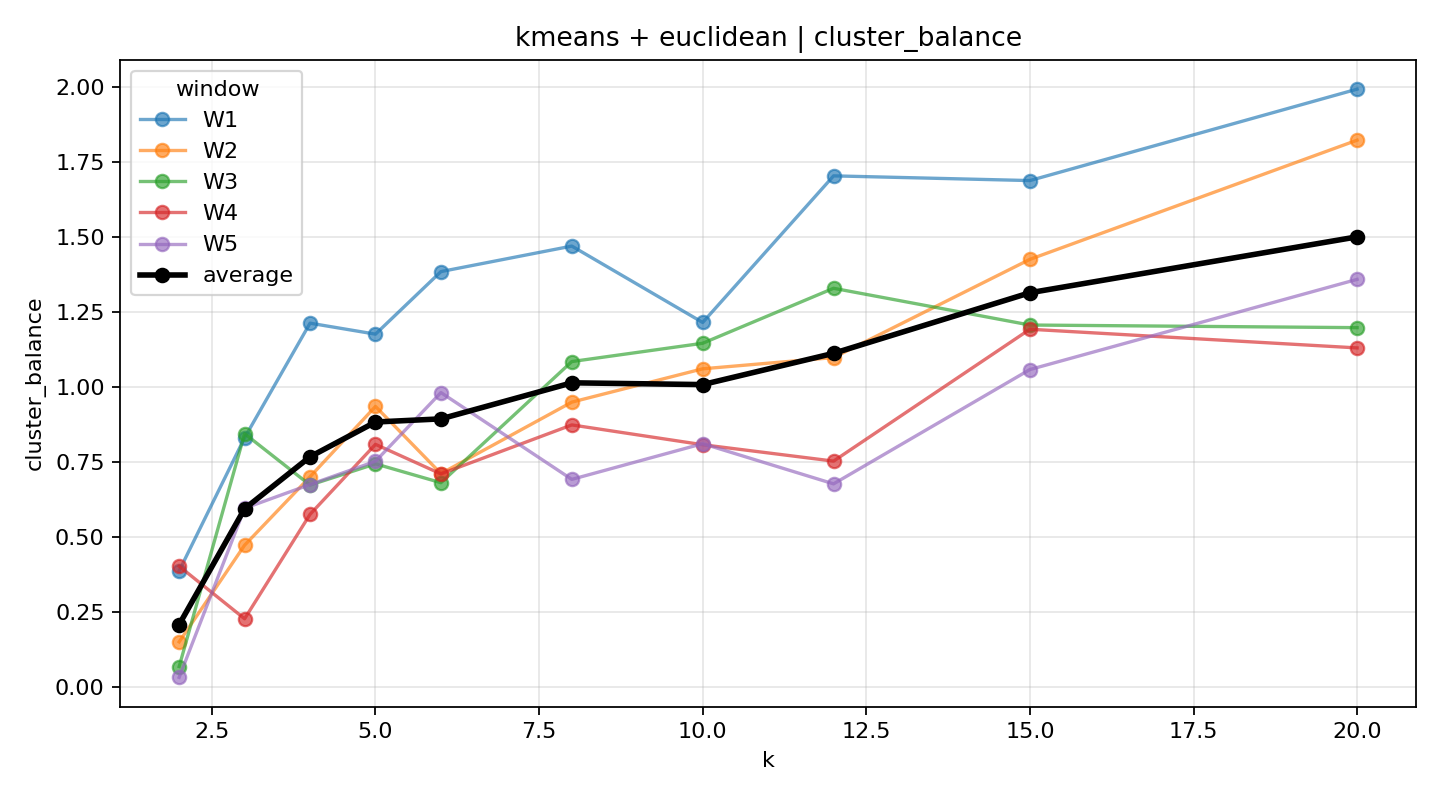

### kmeans_euclidean_davies_bouldin.png

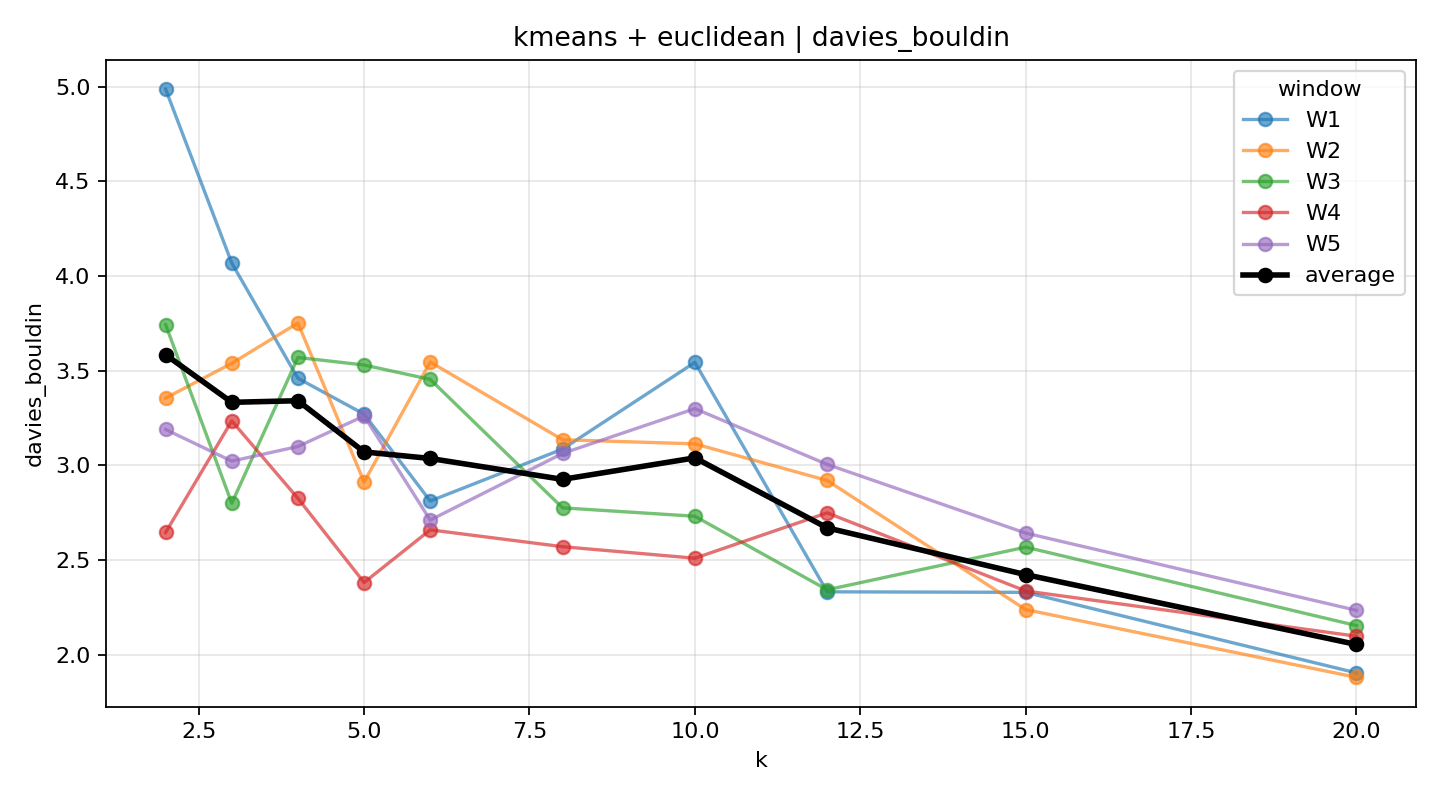

### kmeans_euclidean_silhouette_heatmap.png

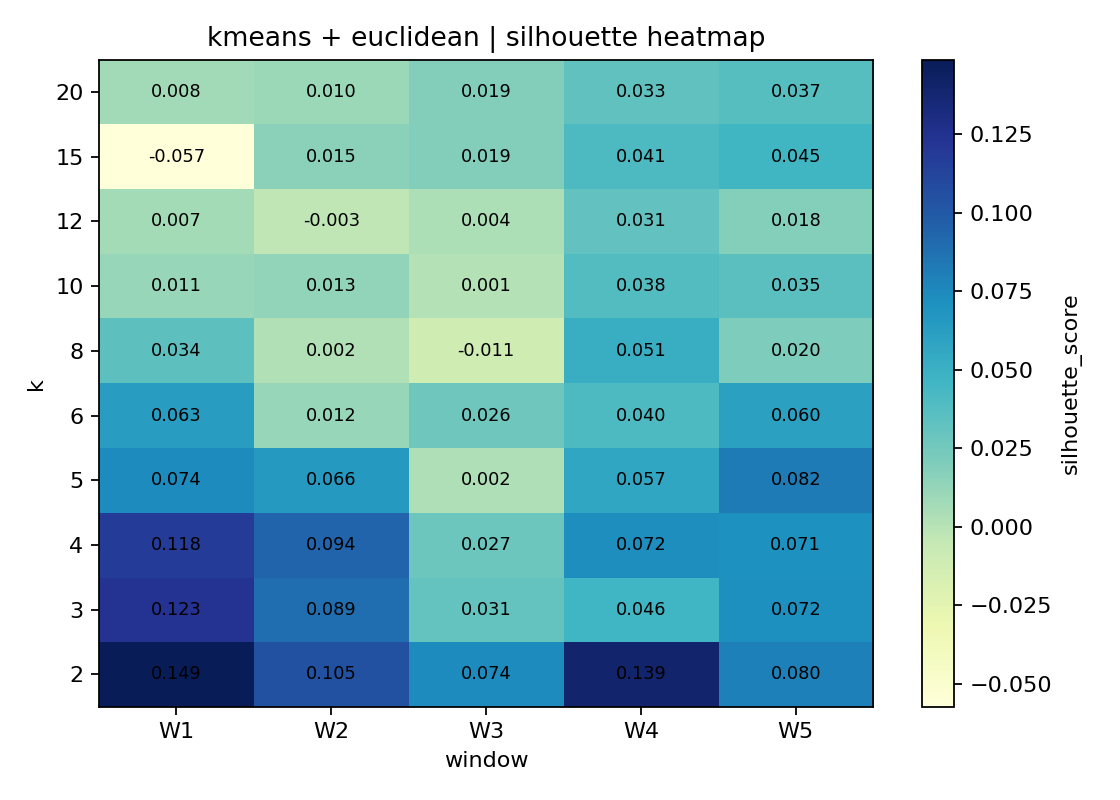

### kmeans_euclidean_silhouette_score.png

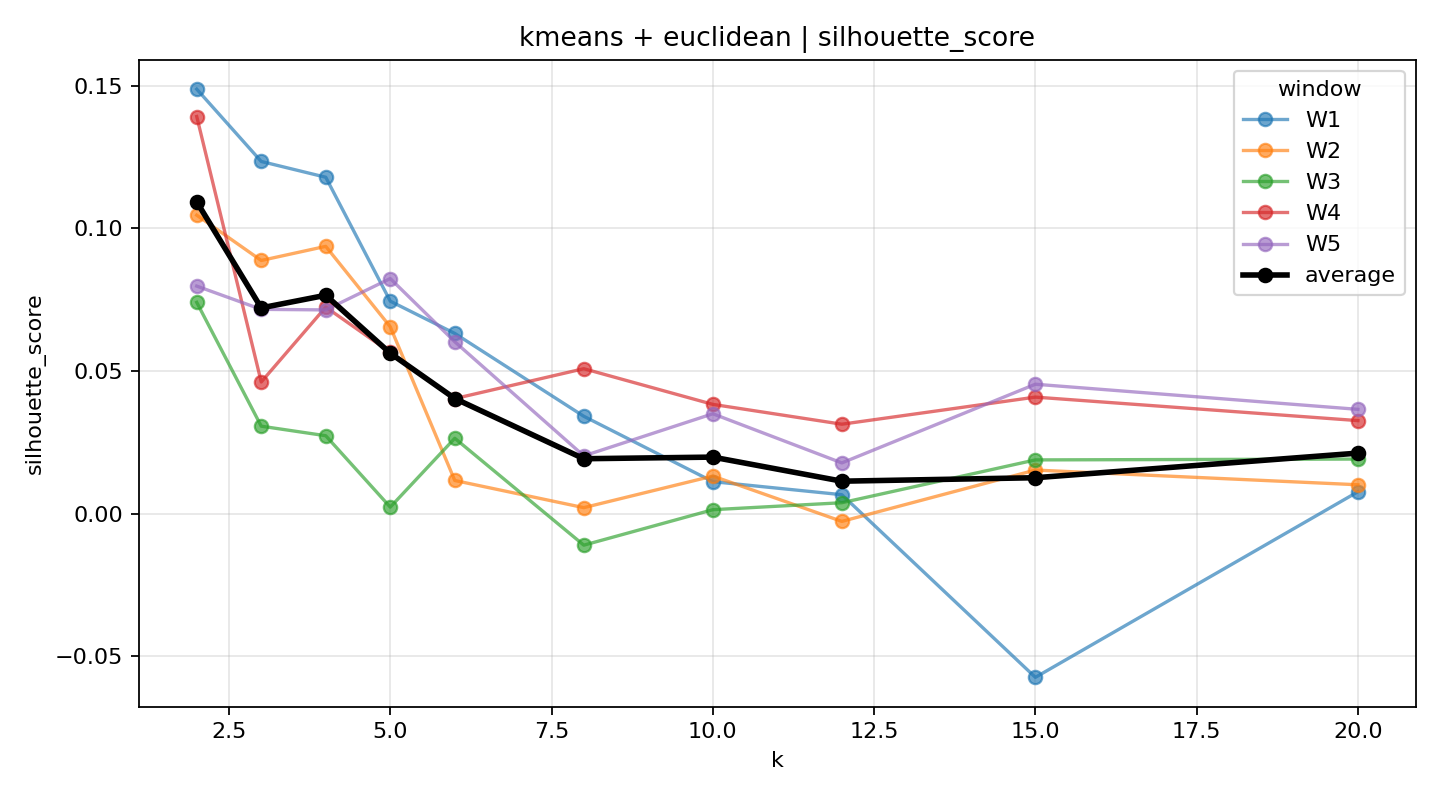

### kmedoids_dtw_cluster_balance.png

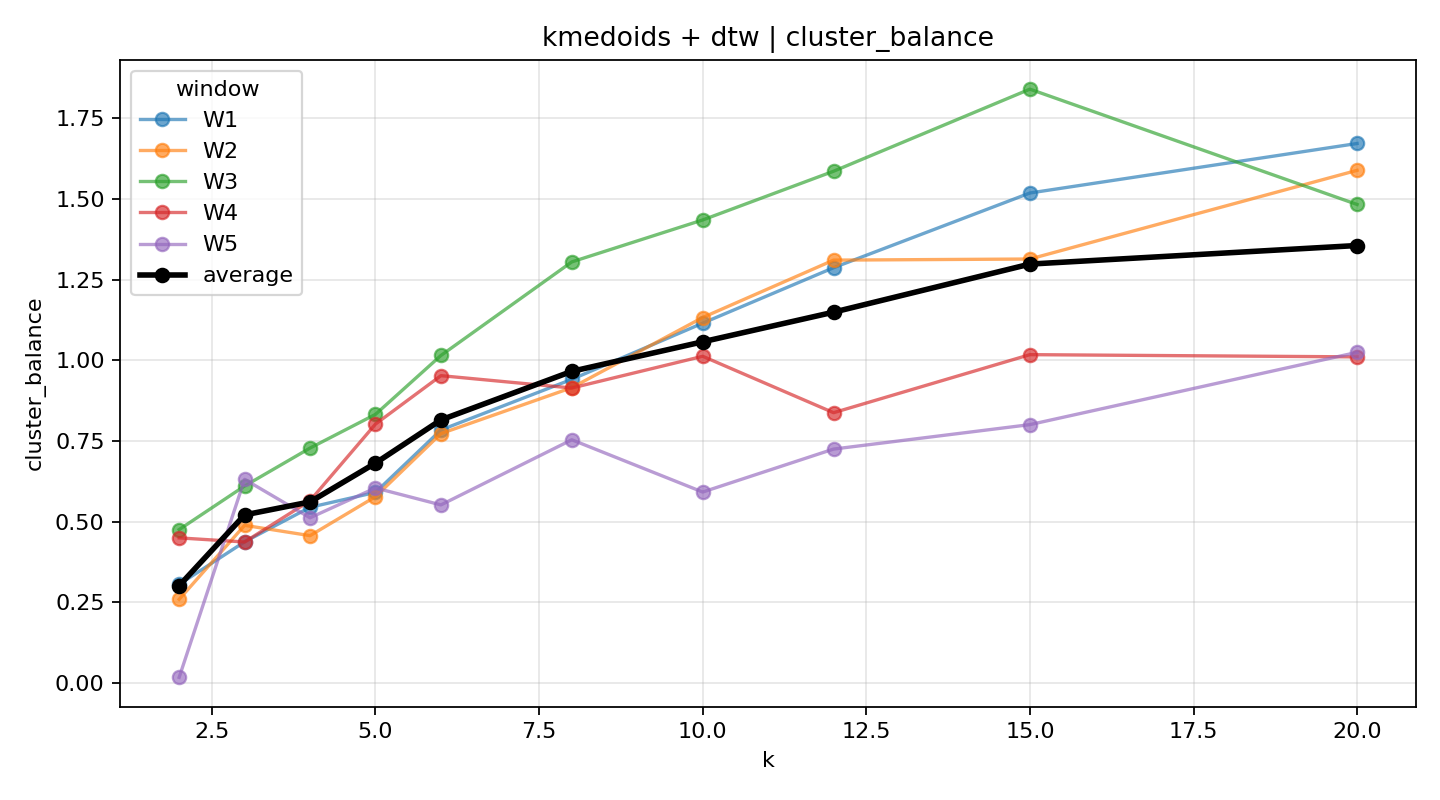

### kmedoids_dtw_davies_bouldin.png

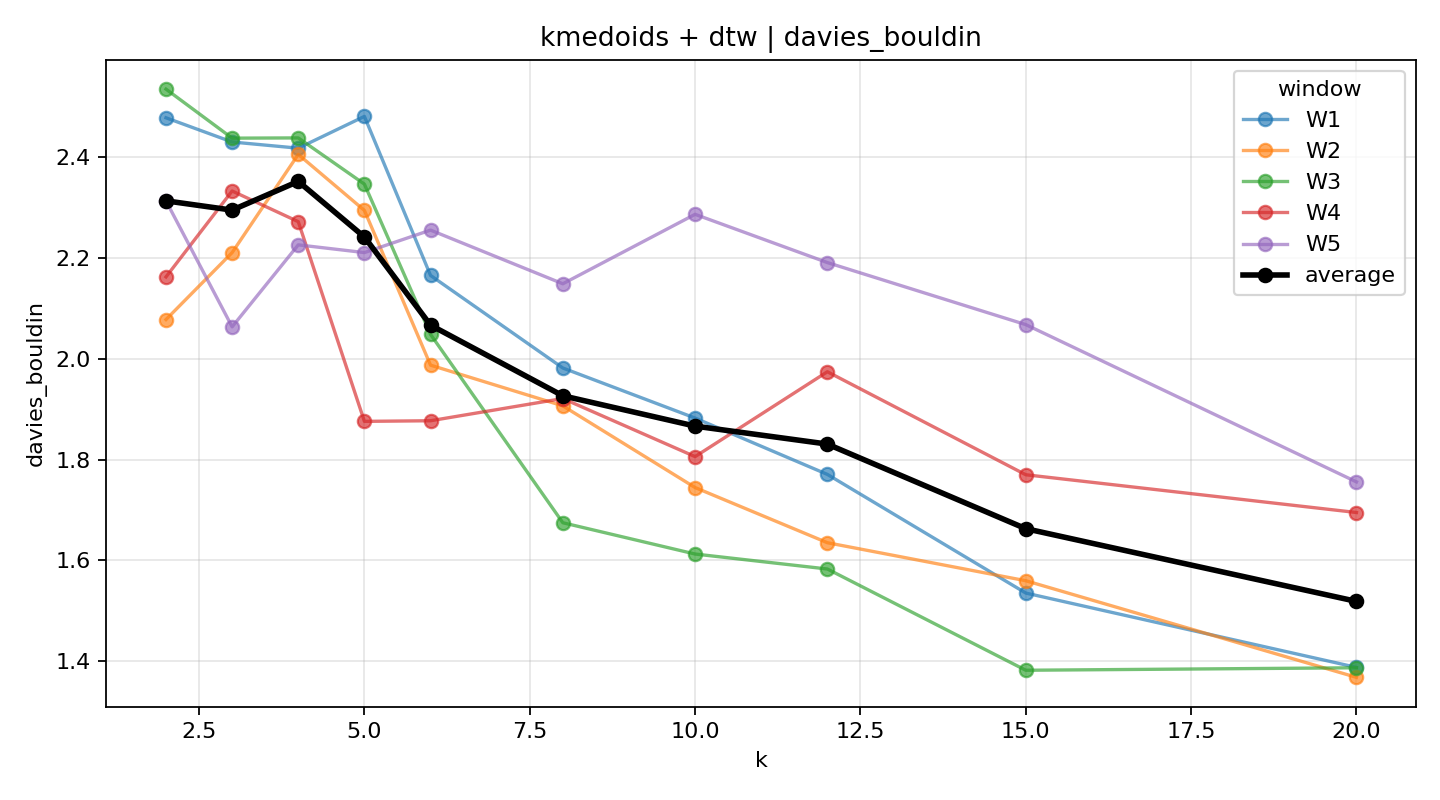

### kmedoids_dtw_silhouette_heatmap.png

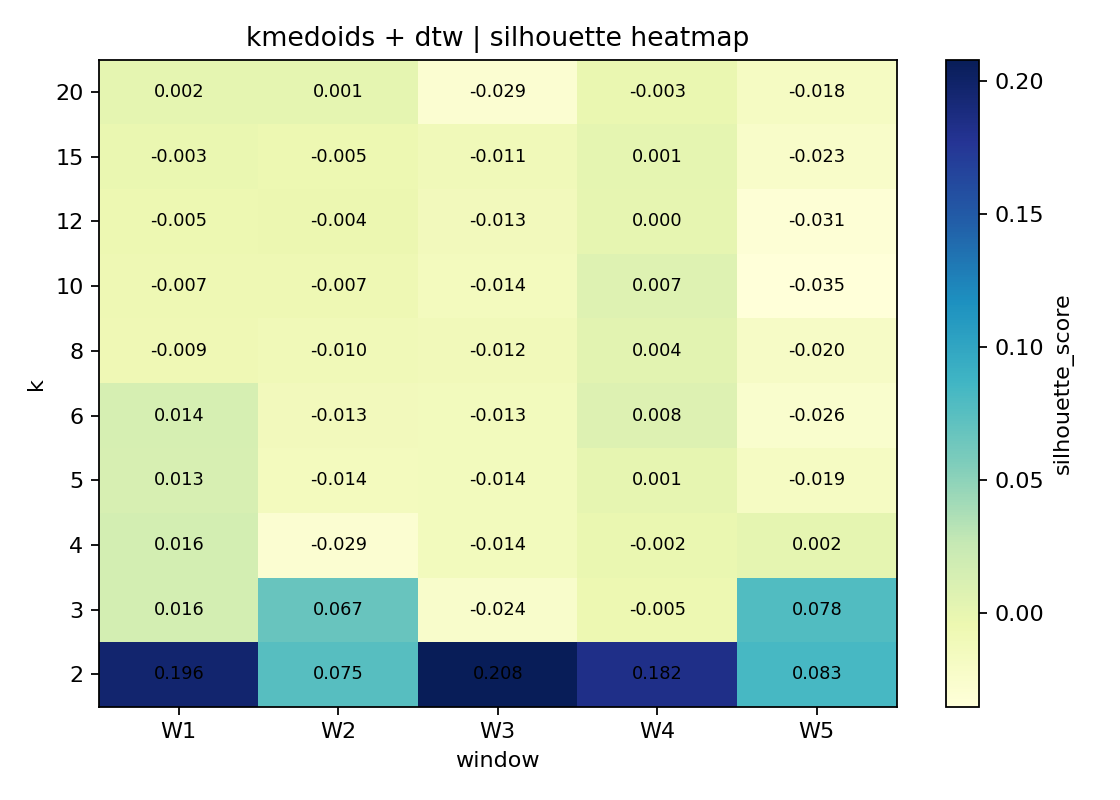

### kmedoids_dtw_silhouette_score.png

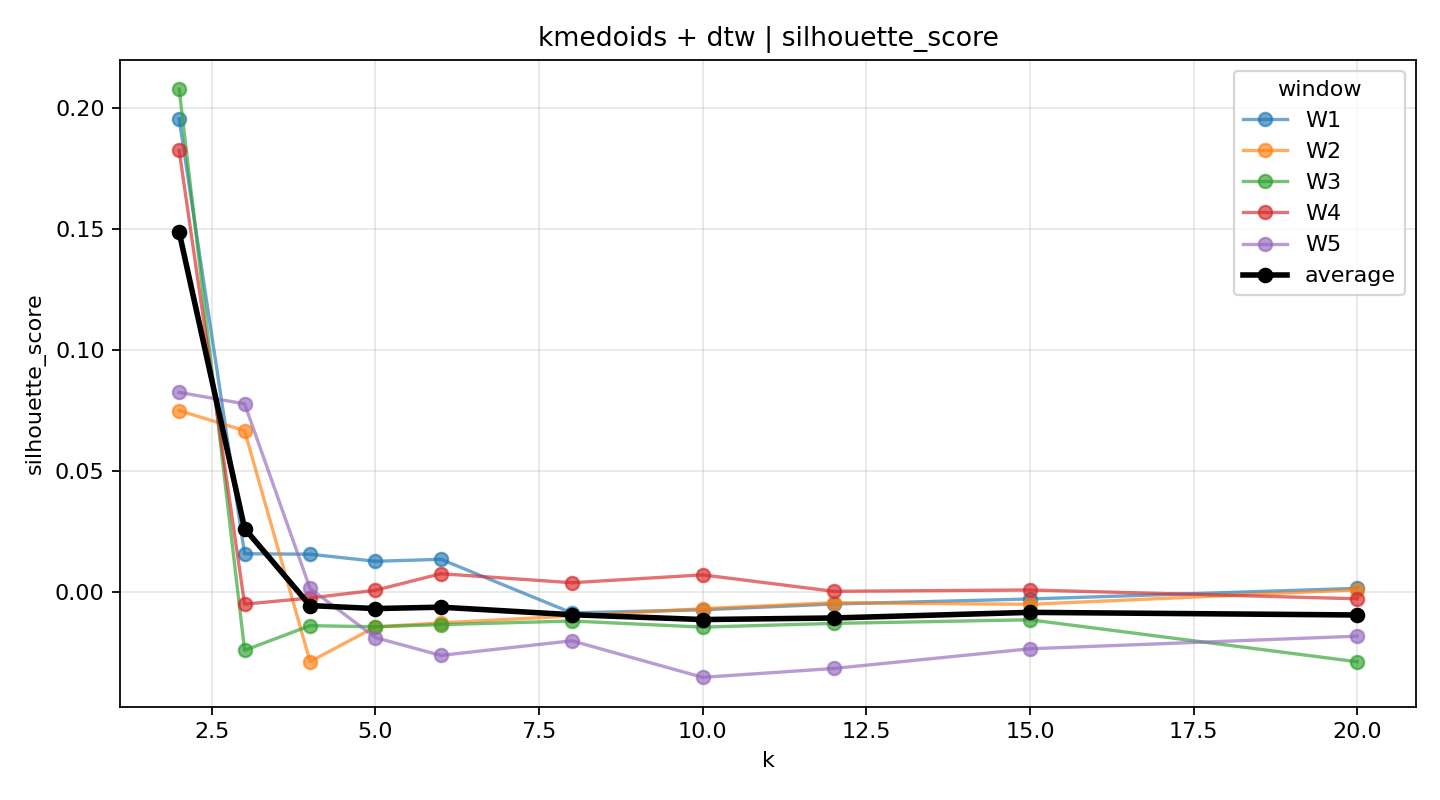

In [54]:
for p in plot_files:
    display(Markdown(f'### {p.name}'))
    display(Image(filename=str(p)))


## 12) Ad-hoc İnceleme Hücreleri

In [55]:
# method-distance bazında, pencere kırılımında hızlı pivot
if not ok_df.empty:
    pivot_sil = ok_df.pivot_table(
        index=['method', 'distance', 'k'],
        columns='window_id',
        values='silhouette_score',
        aggfunc='mean'
    ).reset_index()
    display(pivot_sil.head(30))
else:
    print('No ok rows.')


window_id,method,distance,k,W1,W2,W3,W4,W5
0,kmeans,euclidean,2,0.148775,0.104618,0.074072,0.139189,0.079770
1,kmeans,euclidean,3,0.123433,0.088746,0.030689,0.046170,0.071620
2,kmeans,euclidean,4,0.117908,0.093695,0.027341,0.072409,0.071422
3,kmeans,euclidean,5,0.074492,0.065504,0.002319,0.056544,0.082411
4,kmeans,euclidean,6,0.063186,0.011657,0.026445,0.040348,0.060268
5,kmeans,euclidean,8,0.034155,0.002145,-0.010999,0.050825,0.020285
6,kmeans,euclidean,10,0.011259,0.013209,0.001423,0.038329,0.035036
7,kmeans,euclidean,12,0.006680,-0.002671,0.003867,0.031379,0.017814
8,kmeans,euclidean,15,-0.057314,0.015315,0.018872,0.040872,0.045385
9,kmeans,euclidean,20,0.007717,0.010161,0.019163,0.032639,0.036582


In [56]:
# Ortalama metriklere göre k sıralaması (method-distance ayrı)
if not ok_df.empty:
    avg_metrics = (
        ok_df.groupby(['method', 'distance', 'k'], as_index=False)[['silhouette_score', 'davies_bouldin', 'cluster_balance']]
        .mean()
        .sort_values(['method', 'distance', 'k'])
    )
    display(avg_metrics)
else:
    print('No ok rows.')


,method,distance,k,silhouette_score,davies_bouldin,cluster_balance
0,kmeans,euclidean,2,0.109285,3.583865,0.209254
1,kmeans,euclidean,3,0.072132,3.332660,0.595132
2,kmeans,euclidean,4,0.076555,3.341087,0.768235
3,kmeans,euclidean,5,0.056254,3.070651,0.884056
4,kmeans,euclidean,6,0.040380,3.036105,0.894522
5,kmeans,euclidean,8,0.019282,2.925747,1.014666
6,kmeans,euclidean,10,0.019851,3.039276,1.008737
7,kmeans,euclidean,12,0.011414,2.669504,1.112846
8,kmeans,euclidean,15,0.012626,2.422536,1.314714
9,kmeans,euclidean,20,0.021252,2.053622,1.500932


In [57]:
# Tek kombinasyon çizimi (hızlı)
method = 'kmeans'
distance = 'euclidean'
metric = 'silhouette_score'

sub = ok_df[(ok_df['method'] == method) & (ok_df['distance'] == distance)]
if sub.empty:
    print('No valid rows for selected combo.')
else:
    plt.figure(figsize=(8, 4.5))
    for w, g in sub.groupby('window_id'):
        g = g.sort_values('k')
        plt.plot(g['k'], g[metric], marker='o', alpha=0.7, label=w)
    avg = sub.groupby('k', as_index=False)[metric].mean().sort_values('k')
    plt.plot(avg['k'], avg[metric], marker='o', color='black', linewidth=2.5, label='average')
    plt.title(f'{method} + {distance} | {metric}')
    plt.xlabel('k')
    plt.ylabel(metric)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


/var/folders/wx/0w463w5x7xvdsls9hwjw0vjw0000gn/T/ipykernel_18445/1061937291.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
